### Neurophysiologic signatures of breakpoint

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BIDS = Path.home() / "Library/CloudStorage/GoogleDrive-bzheng112@gmail.com/My Drive/data/PR-iEEG/raw/bids"

def subjects():
    return sorted(p.name[4:] for p in BIDS.glob("sub-*"))

def events(sub):
    f = BIDS / f"sub-{sub}/ses-01/ieeg/sub-{sub}_ses-01_task-pr_events.tsv"
    ev = pd.read_csv(f, sep="\t", na_values="n/a",
                     dtype={"trial_number": "Int64", "reward_level": "Int64", "set_index": "Int64"})
    return ev.sort_values("onset", kind="stable").reset_index(drop=True)

In [2]:
ev = events("P06")
print(len(ev), ev.trial_type.value_counts().to_dict())
ev.head(6)

896 {'trial_start': 439, 'response': 439, 'reward': 15, 'breakpoint': 3}


,onset,duration,trial_type,value,sample,trial_number,reward_level,effort_coeff,set_index
0,159.386,1.692,trial_start,4,159386,1,50,0.12,1
1,161.078,0.000,response,2,161078,<NA>,<NA>,NaN,<NA>
2,161.134,0.835,trial_start,4,161134,2,50,0.12,1
3,161.968,0.000,response,2,161968,2,50,0.12,1
4,162.630,0.645,trial_start,4,162630,4,50,0.12,1
5,163.274,0.000,response,2,163274,<NA>,<NA>,NaN,<NA>


In [3]:
def trial_counts():
    """Trials per reward level for every subject, counted by trial-number span within each set."""
    out = {}
    for sub in subjects():
        ts = events(sub).query("trial_type == 'trial_start'")
        span = ts.groupby(["reward_level", "set_index"])["trial_number"].agg(lambda t: t.max() - t.min() + 1)
        out[sub] = span.groupby("reward_level").sum()
    return pd.DataFrame(out).T.reindex(columns=[50, 25, 10]).fillna(0).astype(int)

In [4]:
counts = trial_counts()
counts

reward_level,50,25,10
P02SB,88,178,70
P06,194,183,73
P10,767,432,173
P12,42,87,71
P13,358,436,0
P14,861,431,172
P15,871,435,174
P16,864,9,0
P17,1,0,175
P18,357,97,91


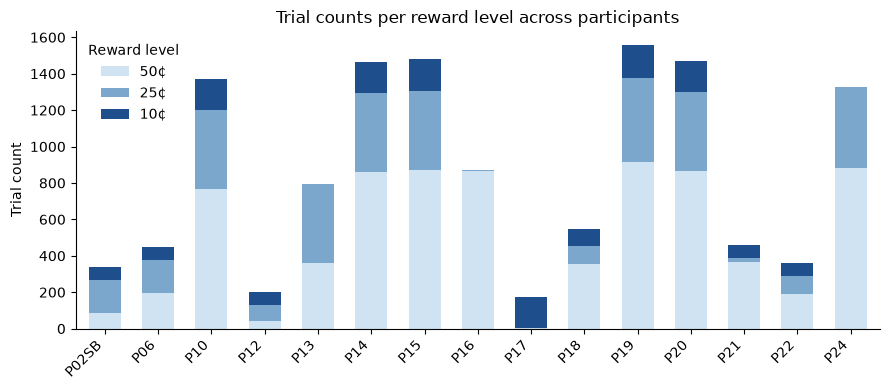

In [5]:
ax = counts.plot.bar(stacked=True, color=["#cfe3f2", "#7ba7cc", "#1f4e8c"], width=0.6, figsize=(9, 4))
ax.set_ylabel("Trial count"); ax.set_xlabel("")
ax.legend(["50¢", "25¢", "10¢"], title="Reward level", frameon=False)
ax.set_title("Trial counts per reward level across participants")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [6]:
def trials():
    """One row per trial across subjects: reward level and response time in ms."""
    rows = []
    for sub in subjects():
        ts = events(sub).query("trial_type == 'trial_start'")
        rows.append(pd.DataFrame({"sub": sub, "reward": ts["reward_level"], "rt_ms": ts["duration"] * 1000}))
    return pd.concat(rows, ignore_index=True)

In [7]:
rt = trials()
rt.groupby(["sub", "reward"])["rt_ms"].median().round().unstack()[[50, 25, 10]]

reward,50,25,10
sub,,,
P02SB,1506.0,1526.0,1370.0
P06,853.0,810.0,836.0
P10,1096.0,1052.0,1073.0
P12,1160.0,1210.0,1151.0
P13,1218.0,1069.0,NaN
P14,1243.0,1186.0,1210.0
P15,951.0,974.0,920.0
P16,889.0,847.0,NaN
P17,1757.0,NaN,1103.0


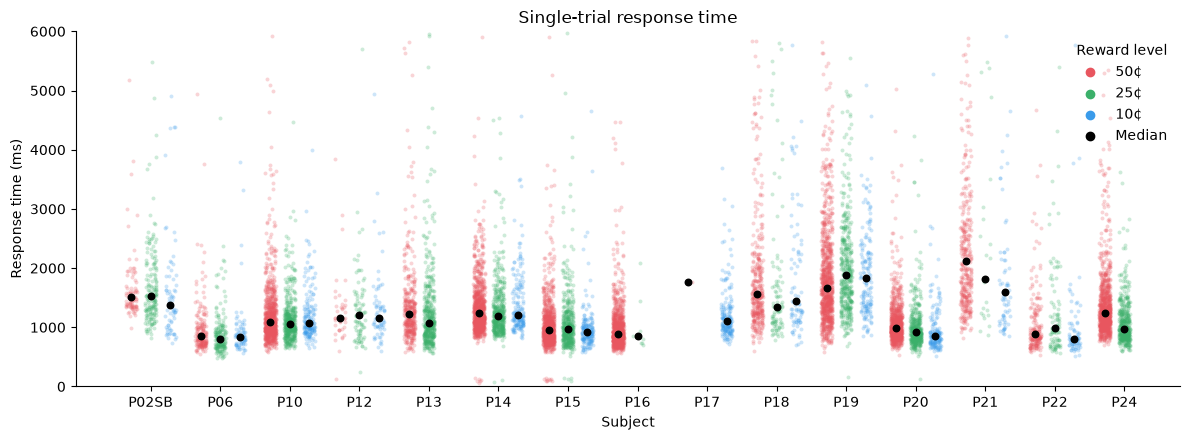

In [8]:
levels, colors, offsets = [50, 25, 10], ["#e8565f", "#3bb06a", "#3a9bea"], [-0.28, 0.0, 0.28]
rng = np.random.default_rng(0)
subs = subjects()

fig, ax = plt.subplots(figsize=(12, 4.5))
for i, sub in enumerate(subs):
    for lev, col, off in zip(levels, colors, offsets):
        y = rt.loc[(rt["sub"] == sub) & (rt["reward"] == lev), "rt_ms"].to_numpy()
        if len(y) == 0:
            continue
        x = i + off + rng.uniform(-0.08, 0.08, len(y))
        ax.scatter(x, y, s=8, color=col, alpha=0.25, linewidths=0)
        ax.scatter(i + off, np.median(y), s=22, color="black", zorder=3)
ax.set_xticks(range(len(subs))); ax.set_xticklabels(subs)
ax.set_ylim(0, 6000); ax.set_ylabel("Response time (ms)"); ax.set_xlabel("Subject")
for lev, col in zip(levels, colors):
    ax.scatter([], [], color=col, label=f"{lev}¢")
ax.scatter([], [], color="black", label="Median")
ax.legend(title="Reward level", frameon=False, loc="upper right")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.set_title("Single-trial response time")
plt.tight_layout()